In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import itertools

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
def intersect_hull_with_hyperplane(
    points: np.ndarray,
    simplices: np.ndarray,
    hyperplane: tuple[np.ndarray, float],
) -> np.ndarray:
    """Find the intersection of a convex hull object with a hyperplane

    The convex hull object is defined by the two variables points, an array of
    the points, and simplicies, which is a list of lists of indices telling you
    which points form each simplex. These basically should look like
    hull.points and hull.simplices.

    The hyperplane should be given as a tuple containing an array n defining
    the normal vector n and a float d such that the hyperplane is defined by
    the equation

    r * n = d

    The output is an array of points that bound the intersection. Note that
    these points may contain redundancies, i.e. may contain additional points
    on the edges of the boundary, rather than purely the vertices. This is a
    feature, not a bug.
    """
    n, d = hyperplane

    # Loop over vertices and compute the signs of r*n - d
    signs = []
    for point in points:
        value = np.dot(n, point) - d

        # Clean up edge cases
        value = 0.0 if np.isclose(value, 0.0) else value

        # Get the sign of r*n -d
        sign = np.sign(value)
        signs.append(sign)

    # Loop over edges and find intersections where they exist
    sorted_edges = set()
    intersections = []
    for simplex in simplices:
        for edge in itertools.combinations(simplex, 2):
            # Check if this edge has been done already. There may be repeats
            # because edges can be shared among multiple simplices
            sorted_edge = tuple(sorted(edge))
            if sorted_edge in sorted_edges:
                continue
            sorted_edges.add(sorted_edge)

            # This is a new edge that hasn't been checked before. Check for
            # intersection
            sign1 = signs[sorted_edge[0]]
            sign2 = signs[sorted_edge[1]]
            product = sign1 * sign2

            # Both vertices lie on the same side of the hyperplane
            if product == 1:
                continue

            v1 = points[sorted_edge[0]]
            v2 = points[sorted_edge[1]]

            # At least one vertex is in the plane
            if product == 0:
                if sign1 == 0:
                    if not any(np.allclose(v1, pt) for pt in intersections):
                        intersections.append(v1)
                if sign2 == 0:
                    if not any(np.allclose(v2, pt) for pt in intersections):
                        intersections.append(v2)
                continue

            # The product must be -1, so there is an intersection
            intersection = v1 + (d - np.dot(v1, n)) / np.dot(v2 - v1, n) * (
                v2 - v1
            )
            intersections.append(intersection)
    return np.array(intersections)

In [3]:
def get_array_index(val: np.float64, array: np.ndarray) -> int:
    """Find the index of a value within a NumPy array.

    Parameters
    ----------
        val : float
            The value to search for.
        array : numpy.ndarray
            The array to search in.

    Returns
    -------
        int
            The index of the first occurrence of the value in the array.
    """
    index: int = np.where(np.isclose(array, val))[0][0]
    return index

In [4]:
def get_degenerate_hull_simplices(
    points: np.ndarray,
) -> np.ndarray:
    """Given a set of points that fill out a lower dimensional subspace of the
    ambient space in which they reside, find a lower dimensional simplex
    decomposition.

    This works by adding in an extra points to the hull to flesh it out into
    the unspanned dimensions. The convex hull of the resulting hull is then
    found. Finally, the additional points are thrown away.

    Example: Image a 2D planar polygon in 3D space. We can imagine
    triangulating it, but scipy won't. Add a point out of the plane of the
    polygon and decompose the resulting 3D shape into simplices. The edges of
    these simplices will also triangulate the original polygon. We then throw
    away the added point and keep the 2D triangulation.
    """
    dimension = points.shape[1]
    new_point = np.random.randn(dimension)
    augmented_points = np.vstack([points, new_point])

    hull = scipy.spatial.ConvexHull(augmented_points)
    new_point_index = get_array_index(hull.points, new_point)

    # Filter out simplices containing the new point index
    mask = ~np.isin(hull.simplices, new_point_index).any(axis=1)
    filtered_simplices = hull.simplices[mask]
    return filtered_simplices

In [5]:
# Define the cube
cube_vertices = 0.5 * np.array(
    [
        [1, 1, 1],
        [1, 1, -1],
        [1, -1, 1],
        [-1, 1, 1],
        [1, -1, -1],
        [-1, 1, -1],
        [-1, -1, 1],
        [-1, -1, -1],
    ]
)
hull = scipy.spatial.ConvexHull(cube_vertices)

np.random.seed(1)
n_1 = np.random.randn(3)
n_1 /= np.linalg.norm(n_1)
n_2 = np.random.randn(3)
n_2 /= np.linalg.norm(n_2)
d_1 = np.random.uniform(-0.4, 0.4)
d_2 = np.random.uniform(-0.4, 0.4)

plane1 = (n_1, d_1)
plane2 = (n_2, d_2)

intersection_one = intersect_hull_with_hyperplane(
    hull.points, hull.simplices, plane1
)

new_simplices = get_degenerate_hull_simplices(intersection_one)
intersection_two = intersect_hull_with_hyperplane(
    intersection_one, new_simplices, plane2
)
print("Intersection of cube with both planes")
print(intersection_two)

Intersection of cube with both planes
[[-0.06691181  0.10285216 -0.10285216]
 [ 0.10513724  0.5        -0.03372817]
 [-0.32807436 -0.5        -0.2077792 ]]


In [6]:
print(n_1, d_1)
print(intersection_one)

[ 0.89529806 -0.33718466 -0.29111491] -0.06464438847736415
[[-0.09793304 -0.5         0.5       ]
 [ 0.14497603  0.14497603  0.5       ]
 [ 0.27868416  0.5         0.5       ]
 [ 0.17204707  0.5         0.17204707]
 [-0.0464756   0.5        -0.5       ]
 [-0.19658982 -0.5         0.19658982]
 [-0.42309281 -0.5        -0.5       ]
 [-0.17055155  0.17055155 -0.5       ]]


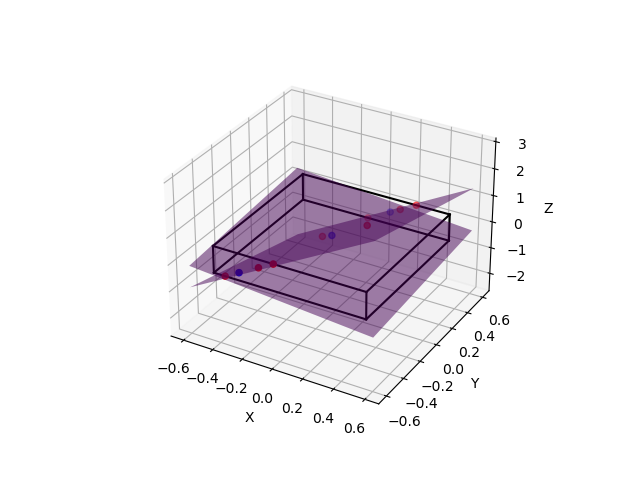

In [7]:
%matplotlib widget

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

# Plot the cube
for i in range(len(cube_vertices)):
    for j in range(i + 1, len(cube_vertices)):
        # Check if they differ by exactly one minus sign
        if np.sum(np.abs(cube_vertices[i] - cube_vertices[j])) == 1:
            # Plot the line segment between the pair
            ax.plot([cube_vertices[i, 0], cube_vertices[j, 0]],
                    [cube_vertices[i, 1], cube_vertices[j, 1]],
                    [cube_vertices[i, 2], cube_vertices[j, 2]], color='black')

# Plot the planes
x = np.linspace(-0.6, 0.6, 100)
y = np.linspace(-0.6, 0.6, 100)
x, y = np.meshgrid(x, y)
a, b, c = plane1[0]
d = plane1[1]
z = (d-a*x-b*y)/c
ax.plot_surface(x, y, z, alpha=0.5, rstride=100, cstride=100, cmap='viridis')

a, b, c = plane2[0]
d = plane2[1]
z = (d-a*x-b*y)/c
ax.plot_surface(x, y, z, alpha=0.5, rstride=100, cstride=100, cmap='viridis')

# Plot the intersection points
ax.scatter(intersection_one[:, 0], intersection_one[:, 1], intersection_one[:, 2], color='red')
ax.scatter(intersection_two[:, 0], intersection_two[:, 1], intersection_two[:, 2], color='blue')
# # Show the plot
# xyz_min = min(x.min(), y.min(), z.min())
# xyz_max = max(x.max(), y.max(), z.max())
ax.plot([cube_vertices[i, 0], cube_vertices[j, 0]],
        [cube_vertices[i, 1], cube_vertices[j, 1]],
        [cube_vertices[i, 2], cube_vertices[j, 2]], color='black')

# ax.set_xlim([xyz_min, xyz_max])
# ax.set_ylim([xyz_min, xyz_max])
# ax.set_zlim([xyz_min, xyz_max])
plt.show()

In [8]:
# ----------------------------------------------------------------
# Test with 4D hypercube
vertices = np.array(list(itertools.product([0, 1], repeat=4)))
centerd_vertices = (vertices - 0.5)
hull = scipy.spatial.ConvexHull(centerd_vertices)
print(hull.volume)

0.9999999999999997


In [9]:
n1 = np.array([0, 0, 0, 1])
n2 = np.array([1, 1, 1, 0])

intersection_one = intersect_hull_with_hyperplane(
    hull.points, hull.simplices, (n1, 0)
)

In [10]:
new_simplices = get_degenerate_hull_simplices(intersection_one)

In [11]:
intersection_two = intersect_hull_with_hyperplane(
    intersection_one, new_simplices, (n2,0)
)

In [12]:
points_2d = []
for point in intersection_two:
    points_2d.append(np.delete(point, [2,3]))
points_2d = np.array(points_2d)

In [13]:
# Find the area from the convex hull
hull_2d = scipy.spatial.ConvexHull(points_2d)
det_factor = np.sqrt(3)
area_hull = det_factor * hull_2d.volume

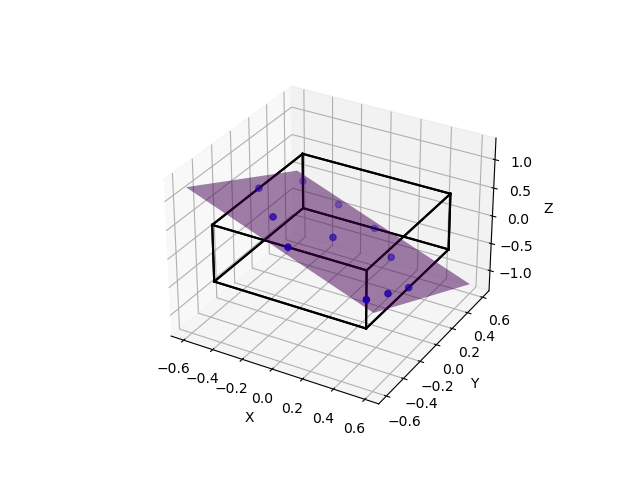

In [14]:
%matplotlib widget

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

# Plot the cube
for i in range(len(centerd_vertices)):
    for j in range(i + 1, len(centerd_vertices)):
        # Check if they differ by exactly one minus sign
        if np.sum(np.abs(centerd_vertices[i] - centerd_vertices[j])) == 1:
            # Plot the line segment between the pair
            ax.plot([centerd_vertices[i, 0], centerd_vertices[j, 0]],
                    [centerd_vertices[i, 1], centerd_vertices[j, 1]],
                    [centerd_vertices[i, 2], centerd_vertices[j, 2]], color='black')

# Plot the planes
x = np.linspace(-0.6, 0.6, 100)
y = np.linspace(-0.6, 0.6, 100)
x, y = np.meshgrid(x, y)
z = -x-y
ax.plot_surface(x, y, z, alpha=0.5, rstride=100, cstride=100, cmap='viridis')

# Plot the intersection points
# ax.scatter(intersection_one[:, 0], intersection_one[:, 1], intersection_one[:, 2], color='red')
ax.scatter(intersection_two[:, 0], intersection_two[:, 1], intersection_two[:, 2], color='blue')
# # Show the plot
# xyz_min = min(x.min(), y.min(), z.min())
# xyz_max = max(x.max(), y.max(), z.max())

# ax.set_xlim([xyz_min, xyz_max])
# ax.set_ylim([xyz_min, xyz_max])
# ax.set_zlim([xyz_min, xyz_max])
plt.show()

In [15]:
# Area of the hexagon
point1 = np.array([0.5,-0.5,0.0])
point2 = np.array([0,-0.5,0.5])
side_length = np.linalg.norm(point1 - point2)
area = 3/2 * np.sqrt(3)*side_length**2
print(f"Area from geometry: {area}")
print(f"Area from hull: {area_hull}")

Area from geometry: 1.2990381056766582
Area from hull: 1.299038105676658


In [16]:
# -----------------------------------------------------------------------------
# Test with 8D hypercube
vertices = np.array(list(itertools.product([0, 1], repeat=8)))
centerd_vertices = (vertices - 0.5)
hull = scipy.spatial.ConvexHull(centerd_vertices)
print(hull.volume)

1.0000000000013192


In [17]:
print(centerd_vertices)

[[-0.5 -0.5 -0.5 ... -0.5 -0.5 -0.5]
 [-0.5 -0.5 -0.5 ... -0.5 -0.5  0.5]
 [-0.5 -0.5 -0.5 ... -0.5  0.5 -0.5]
 ...
 [ 0.5  0.5  0.5 ...  0.5 -0.5  0.5]
 [ 0.5  0.5  0.5 ...  0.5  0.5 -0.5]
 [ 0.5  0.5  0.5 ...  0.5  0.5  0.5]]


In [18]:
n1 = np.array([1, -1, -1, 1, 0, 0, 0, 0])
n2 = np.array([0, 0, 0, 0, 1, -1, -1, 1])

intersection_one = intersect_hull_with_hyperplane(
    hull.points, hull.simplices, (n1, 0)
)

In [19]:
new_simplices = get_degenerate_hull_simplices(intersection_one)

In [20]:
intersection_two = intersect_hull_with_hyperplane(
    intersection_one, new_simplices, (n2,0)
)

In [21]:
print(len(hull.points))
print(len(intersection_one))
print(len(intersection_two))

256
807
803


In [22]:
points_6d = []
for point in intersection_two:
    points_6d.append(np.delete(point, [0,4]))
points_6d = np.array(points_6d)

In [23]:
hull_6d = scipy.spatial.ConvexHull(points_6d)

In [24]:
len(hull_6d.points)

803

In [25]:
intersection_two[153]

array([ 0.5       , -0.16666667,  0.16666667, -0.5       , -0.16666667,
        0.5       , -0.5       ,  0.16666667])

In [26]:
points_6d[153]

array([-0.16666667,  0.16666667, -0.5       ,  0.5       , -0.5       ,
        0.16666667])

In [27]:
hull_6d.volume

0.4444444444444437

In [71]:
def rotation_8d(point, angle):
    P = np.array(
        [
            [1, 0, 1, 1, 1, 0, 0, 0],
            [-1, 0, 1, 1, 0, 0, 0, 0],
            [-1, 0, 1, 0, 1, 0, 0, 0],
            [1, 0, 1, 0, 0, 0, 0, 0],
            [0, 1, 0, 0, 0, 1, 1, 1],
            [0, -1, 0, 0, 0, 1, 1, 0],
            [0, -1, 0, 0, 0, 1, 0, 1],
            [0, 1, 0, 0, 0, 1, 0, 0],
        ]
    )
    P_inv = np.linalg.inv(P)
    R = np.array(
        [
            [np.cos(angle), -np.sin(angle), 0, 0, 0, 0, 0, 0],
            [np.sin(angle), np.cos(angle), 0, 0, 0, 0, 0, 0],
            [0, 0, 1, 0, 0, 0, 0, 0],
            [0, 0, 0, 1, 0, 0, 0, 0],
            [0, 0, 0, 0, 1, 0, 0, 0],
            [0, 0, 0, 0, 0, 1, 0, 0],
            [0, 0, 0, 0, 0, 0, 1, 0],
            [0, 0, 0, 0, 0, 0, 0, 1],
        ]
    )
    new_point = P@R@P_inv@point
    return new_point

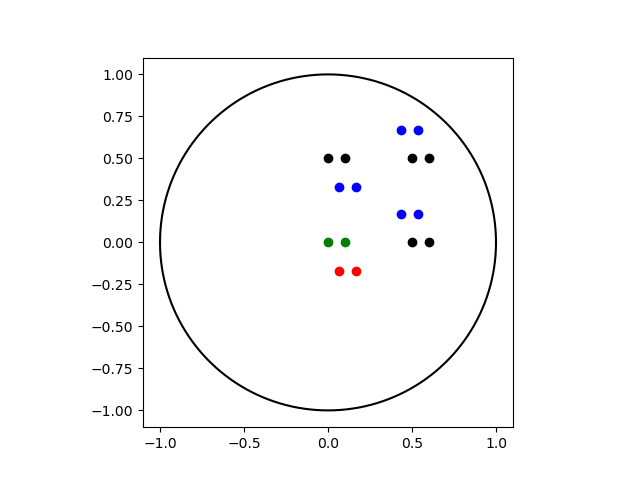

In [73]:
angle = np.random.randn()

before = np.array([0,1,1,0,0,0,1,1])/2
after = rotation_8d(before, angle)

before_two = before + np.array([1,1,1,1,0,0,0,0])/10
after_two = rotation_8d(before_two, angle)

fig, ax = plt.subplots()
t = np.linspace(-1,1,10**4)
y = np.sqrt(1-t**2)
ax.plot(t,y,color="black")
ax.plot(t,-y,color="black")
ax.set_aspect("equal")

ax.scatter(before[0],before[4],color="green")
ax.scatter(before[1],before[5],color="black")
ax.scatter(before[2],before[6],color="black")
ax.scatter(before[3],before[7],color="black")
ax.scatter(before_two[0],before_two[4],color="green")
ax.scatter(before_two[1],before_two[5],color="black")
ax.scatter(before_two[2],before_two[6],color="black")
ax.scatter(before_two[3],before_two[7],color="black")

ax.scatter(after[0],after[4],color="red")
ax.scatter(after[1],after[5],color="blue")
ax.scatter(after[2],after[6],color="blue")
ax.scatter(after[3],after[7],color="blue")
ax.scatter(after_two[0],after_two[4],color="red")
ax.scatter(after_two[1],after_two[5],color="blue")
ax.scatter(after_two[2],after_two[6],color="blue")
ax.scatter(after_two[3],after_two[7],color="blue")



In [ ]:
def to_8d(p):
    return np.array([p[0,0],p[1,0],p[2,0],p[3,0],f[1],f[3],f[5],f[7]])

In [ ]:
def to_2d(point):
    f = np.ravel(point)
    new = np.array([f[0],f[2],f[4],f[6],f[1],f[3],f[5],f[7]])
    return new

In [37]:
# Starting points
square_one = np.array([[0,0],[1,0],[1,1],[0,1]])/10
square_two = square_one + np.array([0.1,0.0])
square_three = square_one + np.array([0.0,0.1])
square_four = square_one + np.array([0.1,0.1])

rotation_angle = np.pi/2
new_square_one = rotation_8d(square_one.T, rotation_angle)
new_square_two = rotation_8d(square_two.T, rotation_angle)
new_square_three = rotation_8d(square_three.T, rotation_angle)
new_square_four = rotation_8d(square_four.T, rotation_angle)

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 8)